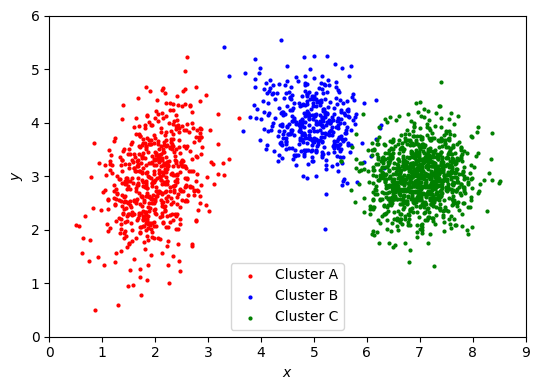

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

np.random.seed(107)

# Define 3 gaussian clusters then stack all points together
means = [
    [2, 3],
    [5, 4],
    [7, 3]
]

covariances = [
    [[0.25, 0.125], [0.125, 0.5]],
    [[0.25, -0.075], [-0.075, 0.25]],
    [[0.25, 0], [0, 0.25]]
]

colors = ['red', 'blue', 'green']
num_points = [600, 400, 1000]

points = []
labels = []
point_colors = []

for mean, cov, n, color in zip(means, covariances, num_points, colors):
    data = np.random.multivariate_normal(mean, cov, n)
    points.append(data)
    labels.extend([color] * n)
    point_colors.extend([color] * n)

all_points = np.vstack(points)

# Plot all distributions on the same graph
fig, ax = plt.subplots(1, 1, figsize=(5.5, 4))

cluster_labels = ['A', 'B', 'C']

for data, color, label in zip(points, colors, cluster_labels):
    ax.scatter(data[:, 0], data[:, 1], color=color, s=4, alpha=1, label=f'Cluster {label}')

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_xlim(0, 9)
ax.set_ylim(0, 6)
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.legend()

fig.tight_layout()
plt.show()

Did the GMM converge: Yes
Time taken: 1.56 seconds


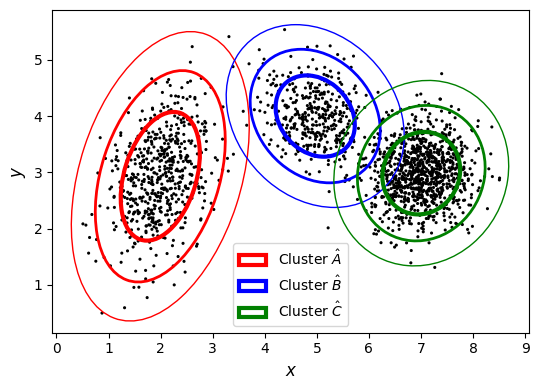

In [37]:
from matplotlib.patches import Ellipse
from sklearn.mixture import GaussianMixture
from scipy.stats import chi2
import time

def gaussian_mixture_procedure(data, n_clusters, n_init, max_iter, message=True):
    gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', n_init=n_init, init_params='kmeans', max_iter=max_iter)
    start_time = time.time()
    gmm.fit(data)
    if message:
        print("Did the GMM converge:", "Yes" if gmm.converged_ else "No")
        print(f"Time taken: {time.time() - start_time:.2f} seconds")
    
    labels = gmm.predict(data)

    return gmm, labels

def plot_gmm_contours(gmm, X_log, ax, labels, conf_levels=[0.683, 0.955, 0.997], lw_list=[3, 2, 1]):
    colors = ['red', 'blue', 'green', 'purple', 'orange']
    
    # Sort GMM components by the x-value of the means, ensuring constant ellipse ordering
    sorted_indices = np.argsort(gmm.means_[:, 0])
    sorted_means = gmm.means_[sorted_indices]
    sorted_covariances = gmm.covariances_[sorted_indices]
    sorted_weights = gmm.weights_[sorted_indices]
    
    for i, (mean, covar, weight) in enumerate(zip(sorted_means, sorted_covariances, sorted_weights)):
        eigenvalues, eigenvectors = np.linalg.eigh(covar)
        angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
        
        # Draw ellipses for all confidence levels
        for conf, lw in zip(conf_levels, lw_list):
            v = np.sqrt(chi2.ppf(conf, 2))
            width, height = 2 * v * np.sqrt(eigenvalues)
            
            # Only label the first (largest) ellipse per cluster
            if conf == conf_levels[0]:
                label = rf"Cluster $\hat{{{labels[i]}}}$"
            else:
                label = None

            ellipse = Ellipse(
                mean, width, height,
                angle=angle,
                edgecolor=colors[i % len(colors)],
                facecolor='none',
                linewidth=lw,
                label=label
            )
            ax.add_patch(ellipse)

n_clusters = 3
n_init = 100
max_iter = 100
test_gmm, labels = gaussian_mixture_procedure(data=all_points, n_clusters=n_clusters, n_init=n_init, max_iter=max_iter)

fig, ax = plt.subplots(1, 1, figsize=(5.5, 4))
ax.scatter(all_points[:, 0], all_points[:, 1], s=5, alpha=1, edgecolors='none', color='k')

ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$y$', fontsize=12)

plot_gmm_contours(gmm=test_gmm, X_log=data, ax=ax, labels=cluster_labels)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")

ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

ax.legend()

fig.tight_layout()
plt.show()